In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

# 05 — Standard 2D Printability Map: Laser Power vs Scan Speed

This is the classic L-PBF processing map: a 2D grid of laser power vs scan speed, coloured
by defect type. This notebook shows the full workflow from grid definition to
publication-ready plot using the complete defect plugin suite.

---

## Section 1 — Imports and Material

We import all layers of the object hierarchy:
- **`Material`** — thermophysical constants (from the built-in database).
- **`ProcessParameters`** — machine configuration (laser power, scan speed, etc.).
- **`MeltPool`** — physics hub that computes melt pool dimensions.
- **`PrintabilitySpace`** — master orchestrator that evaluates the defect map.
- **Defect plugins** — each lives in its own file and implements a `check(melt_pool)` interface.

In [4]:
import numpy as np

from lpbf_map import Material, ProcessParameters, MeltPool, PrintabilitySpace
from lpbf_map.defects import (
    DefectSuite,
    LackOfFusionCriterion,
    BallingPlateauRayleighCriterion,
    KeyholeGanCriterion,
)

# Load Ti-6Al-4V from the built-in library
material = Material.from_library('Ti64')

print(f'Material : {material.name}')
print(f'T_melt   : {material.melting_temperature} K')
print(f'k        : {material.thermal_conductivity} W/(m·K)')
print(f'alpha    : {float(material.thermal_diffusivity):.3e} m²/s')

Material : Ti-6Al-4V
T_melt   : 1877.0 K
k        : 38.0 W/(m·K)
alpha    : 1.200e-05 m²/s


---

## Section 2 — Define the 2D Parameter Grid

The standard printability map sweeps **laser power** (rows) against **scan speed** (columns).
We use NumPy broadcasting to avoid building explicit meshgrids — `ProcessParameters` handles
the broadcast internally and exposes the resulting `shape` property.

The grid below has 40 laser power levels × 40 scan speed levels = **1 600 evaluation points**.

In [5]:
# Column vector: laser_power varies down the rows   [W]
laser_powers = np.linspace(50, 400, 40)[:, np.newaxis]

# Row vector: scan_speed varies across the columns  [m/s]
scan_speeds = np.linspace(0.3, 3.0, 40)[np.newaxis, :]

params = ProcessParameters(
    laser_power=laser_powers,
    scan_speed=scan_speeds,
    beam_radius=40e-6,       # [m] — 40 µm 1/e² radius
    hatch_spacing=80e-6,     # [m] — 80 µm hatch spacing
    layer_thickness=30e-6    # [m] — 30 µm powder layer
)

print(f'Parameter grid shape: {params.shape}')  # -> (40, 40)

Parameter grid shape: (40, 40)


---

## Section 3 — Create the MeltPool

The `MeltPool` object holds references to the `Material` and `ProcessParameters` but **does
not run any solvers yet**. Physics (Rubenchik + Gladush-Smurov hybrid) is computed lazily —
only when `.dimensions`, `.length`, `.width`, or `.depth` are first accessed.

This design means constructing even a 40 × 40 `MeltPool` is instantaneous.

In [6]:
# Instantiate the MeltPool — no computation yet, just a data proxy
pool = MeltPool(material, params)

print(f'MeltPool material: {pool.material.name}')
print(f'MeltPool grid shape: {pool.parameters.shape}')
print('Physics runs lazily — solvers will execute when defects are first evaluated.')

MeltPool material: Ti-6Al-4V
MeltPool grid shape: (40, 40)
Physics runs lazily — solvers will execute when defects are first evaluated.


---

## Section 4 — Assemble the DefectSuite

The **plugin system** decouples defect criteria from physics. Each criterion is an independent
class that implements a `check(melt_pool, index)` method.

`DefectSuite.add(priority_id, criterion)` registers a criterion. The **priority order** is
critical: at each grid point, criteria are checked in ascending `priority_id` order. The
**first criterion that triggers** wins and the remaining checks are skipped. This creates a
strict dominance hierarchy:

1. **Balling** (priority 1) — checked first because balling at any power/speed dominates.
2. **Lack of Fusion** (priority 2) — checked second; typically at low power or high speed.
3. **Keyhole** (priority 3) — checked last; occurs at high power or low speed.

In [7]:
suite = DefectSuite()

# Priority 1: Plateau–Rayleigh balling criterion
suite.add(1, BallingPlateauRayleighCriterion())

# Priority 2: Lack-of-fusion criterion (melt depth vs layer thickness)
suite.add(2, LackOfFusionCriterion())

# Priority 3: Gan keyhole porosity criterion (normalised enthalpy)
suite.add(3, KeyholeGanCriterion())

print('Registered defect criteria (in priority order):')
for priority_id, criterion in suite.criteria:
    print(f'  [{priority_id}] {criterion.__class__.__name__}')

Registered defect criteria (in priority order):
  [1] BallingPlateauRayleighCriterion
  [2] LackOfFusionCriterion
  [3] KeyholeGanCriterion


---

## Section 5 — Run the Printability Evaluation

`PrintabilitySpace` orchestrates everything: it iterates over every point in the parameter
grid, extracts a local `MeltPool` snapshot via `get_point()`, and feeds it through the
`DefectSuite`. The result is stored in `space.defect_map` — an integer array with the same
shape as the parameter grid.

Integer codes:
- `0` — Safe (no defect)
- `1` — Balling
- `2` — Lack of Fusion
- `3` — Keyhole

In [8]:
# Construct the PrintabilitySpace — no computation yet
space = PrintabilitySpace(pool, suite)

# Run the full defect evaluation across all 1600 grid points
# This triggers the melt pool physics solvers — may take 1–3 minutes
space.evaluate()

print(f'Defect map shape   : {space.defect_map.shape}')
print(f'Defect label map   : {space.defect_labels}')

import numpy as np
unique, counts = np.unique(space.defect_map, return_counts=True)
print('\nGrid point breakdown:')
for uid, cnt in zip(unique, counts):
    print(f'  {space.defect_labels[uid]:20s}: {cnt:5d} points ({100*cnt/space.defect_map.size:.1f}%)')

Defect map shape   : (40, 40)
Defect label map   : {0: 'Safe', 1: 'BallingPlateauRayleigh', 2: 'LackOfFusion', 3: 'KeyholeGan'}

Grid point breakdown:
  Safe                :    76 points (4.8%)
  BallingPlateauRayleigh:   904 points (56.5%)
  LackOfFusion        :   370 points (23.1%)
  KeyholeGan          :   250 points (15.6%)


---

## Section 6 — Plot the 2D Map

`space.plot_2d()` accepts the **exact `ProcessParameters` field names** as `x_axis` and
`y_axis`. Axis labels are auto-generated from those names (underscores replaced by spaces,
title-cased).

The function internally calls `space.slice_2d()` to extract coordinate grids, then renders
Gaussian-smoothed contour fills with a strict priority ordering (higher-priority defects are
always drawn on top).

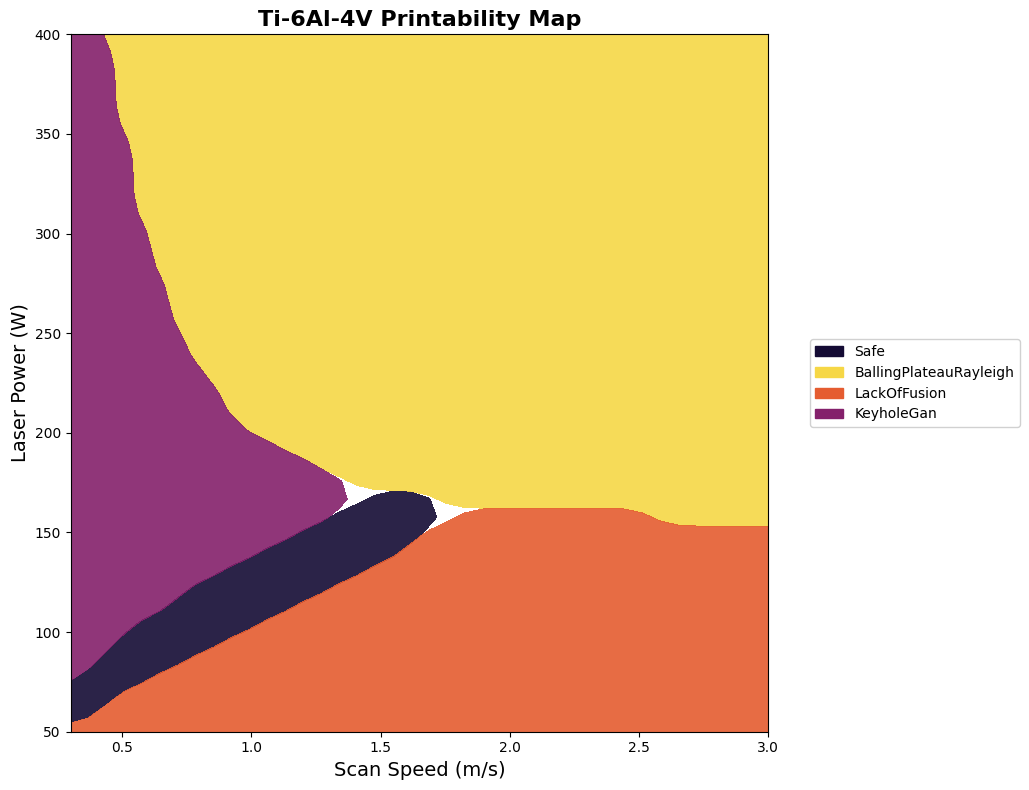

In [10]:
# Plot the 2D printability map
# x_axis and y_axis must match ProcessParameters attribute names exactly
# fig, ax = space.plot_2d(x_axis='scan_speed', y_axis='laser_power')

# Uncomment to save a PNG:
fig, ax = space.plot_2d(x_axis='scan_speed', y_axis='laser_power',
                       save_path='plots/ti64_printability_map.png')

---

## Section 7 — Inspecting Specific Grid Points

The `PrintabilitySpace` API provides several **deep-traversal methods** for interrogating the
computed results without reaching into internal data structures:

| Method | Description |
|---|---|
| `space.len(name)` | Size of the first dimension of a named parameter array |
| `space.get_material_property(name)` | Any attribute from the associated `Material` |
| `space.get_parameter_value(name, idx)` | Physical value of a parameter at a specific index |
| `space.slice_2d(x, y)` | Raw grids and defect slice for custom plotting |

In [11]:
# --- Inspection API ---

# How many distinct scan speed values are there?
n_speeds = space.len('scan_speed')
print(f'Number of scan_speed grid points : {n_speeds}')  # -> 40

# Retrieve a material constant via the traversal API
t_melt = space.get_material_property('melting_temperature')
print(f'Material melting temperature     : {float(t_melt):.1f} K')  # -> 1877.0

# What laser power (W) is at grid index (row=20, col=10)?
power_at_20_10 = space.get_parameter_value('laser_power', (20, 10))
print(f'Laser power at index (20, 10)    : {power_at_20_10:.1f} W')

# Extract the raw data arrays for custom downstream plotting
x_grid, y_grid, defect_slice = space.slice_2d('scan_speed', 'laser_power')
print(f'slice_2d output shapes           : x={x_grid.shape}, y={y_grid.shape}, defect={defect_slice.shape}')

Number of scan_speed grid points : 1
Material melting temperature     : 1877.0 K
Laser power at index (20, 10)    : 229.5 W
slice_2d output shapes           : x=(40, 40), y=(40, 40), defect=(40, 40)


## Section 8 — Individual Defect Visualizations

By default, the unified printability map resolves overlaps using the DefectSuite priority. Lower priority IDs mask higher ones. To visualize exactly where *every* active plugin triggers independently across the whole map (ignoring priority masks), use `.plot_individual_defects()`.

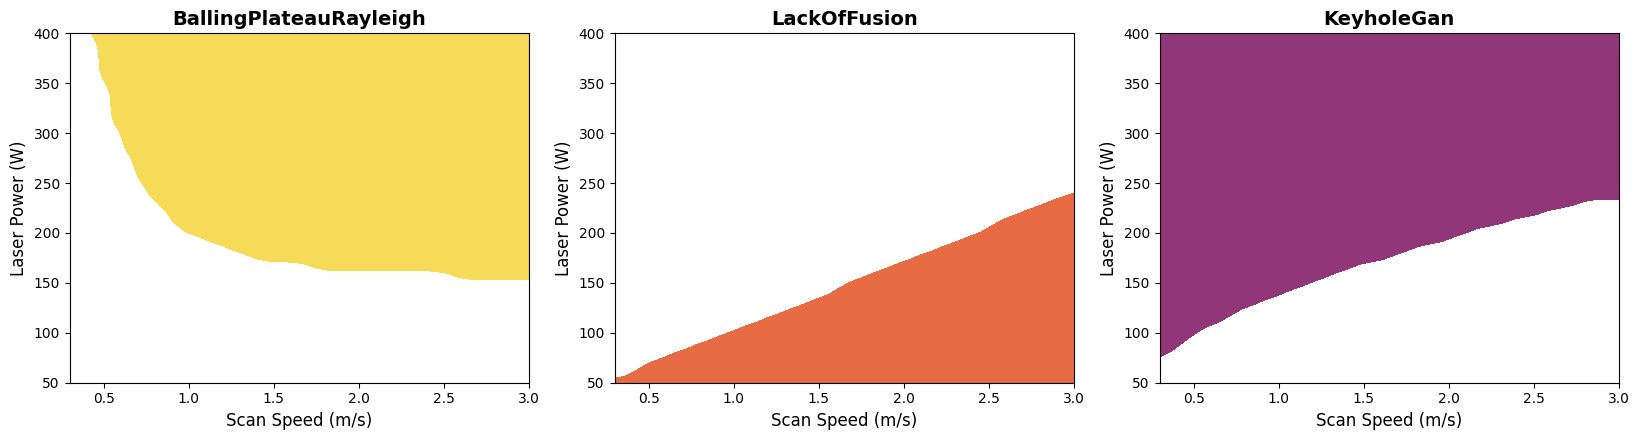

In [12]:
fig, axes = space.plot_individual_defects(x_axis='scan_speed', y_axis='laser_power', save_path='plots/ti64_single_defects_map.png')

## Section 9 — Comprehensive Library Printability Map

Let's evaluate the printability space using all available criteria in the library.

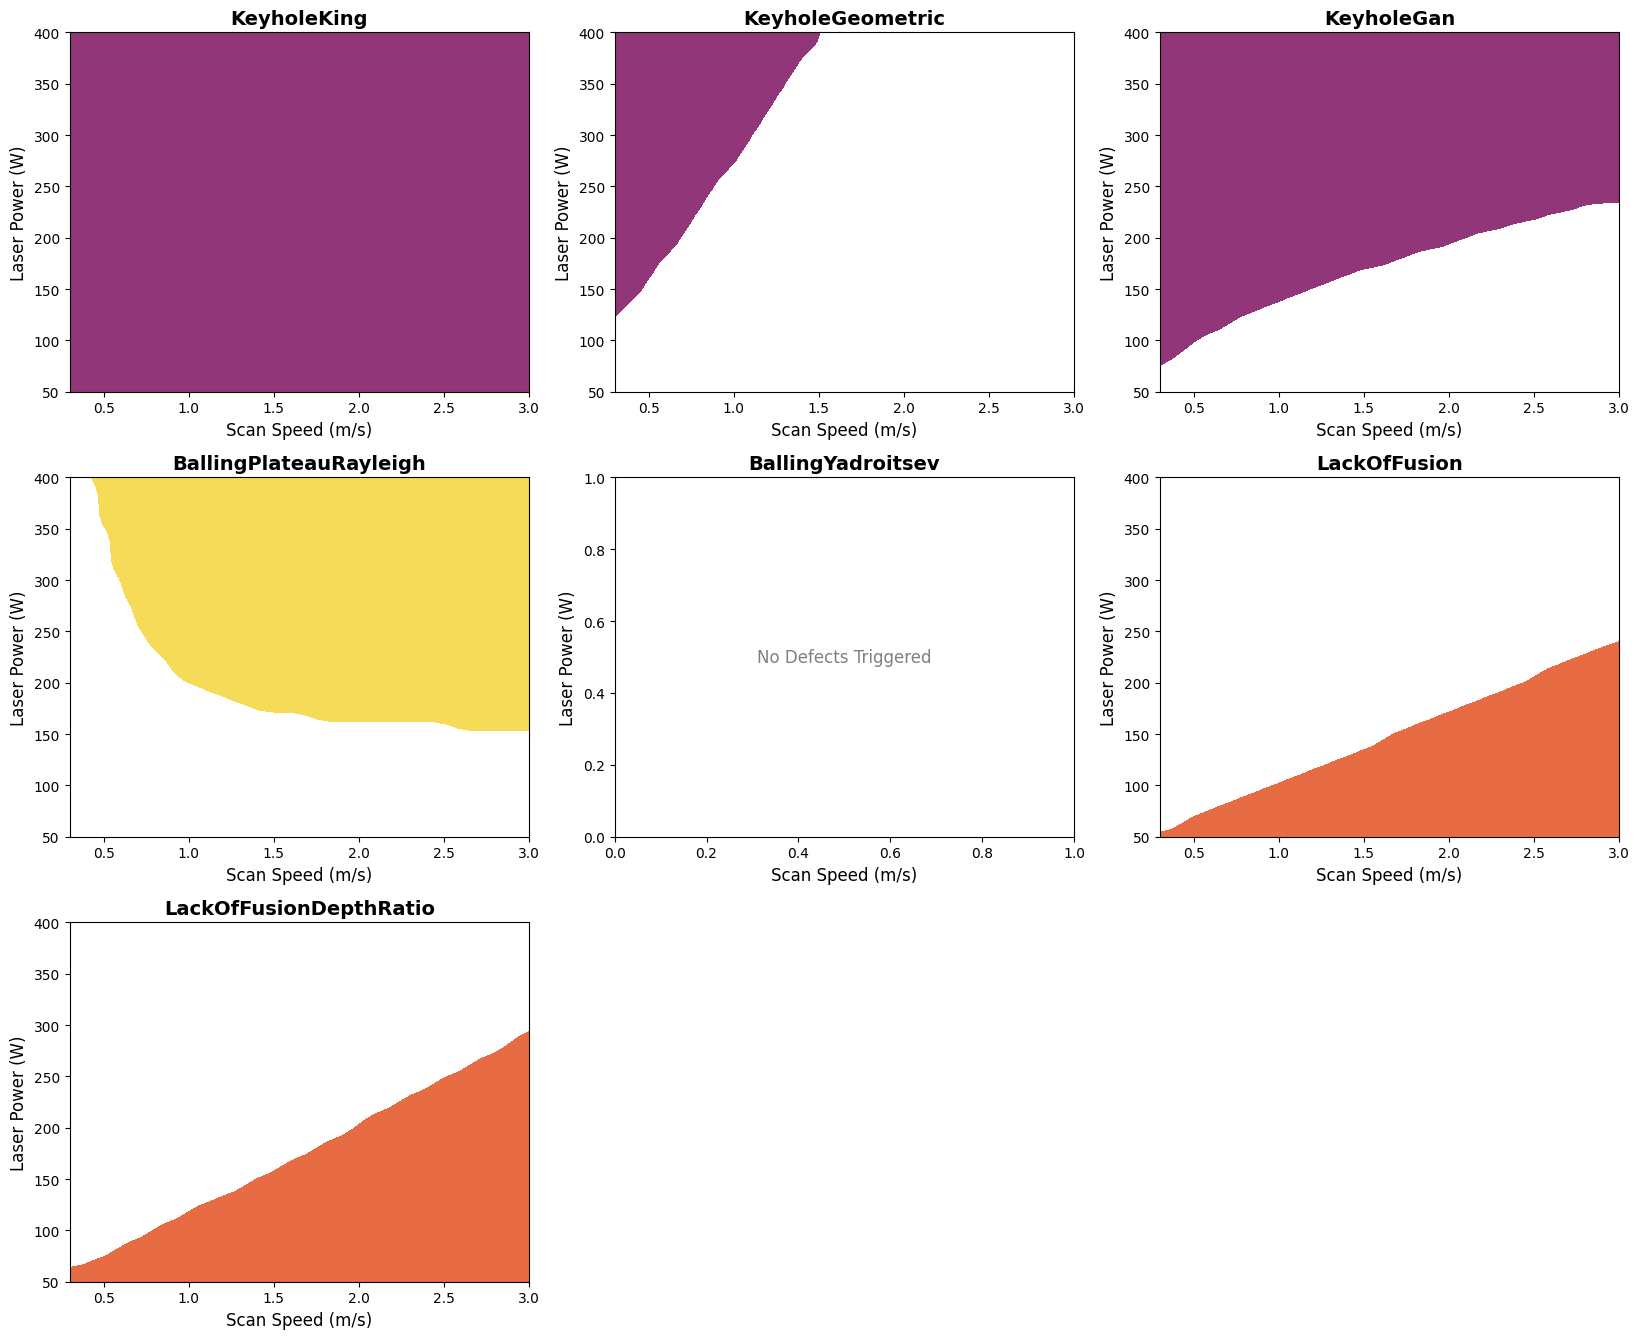

In [13]:
import matplotlib.pyplot as plt
from lpbf_map.defects import (
    BallingPlateauRayleighCriterion,
    BallingYadroitsevCriterion,
    KeyholeGanCriterion,
    KeyholeGeometricCriterion,
    KeyholeKingCriterion,
    LackOfFusionCriterion,
    LackOfFusionDepthRatioCriterion
)

# Create a new suite
all_suite = DefectSuite()

# Priority 1: Keyholing
all_suite.add(1, KeyholeKingCriterion())
all_suite.add(2, KeyholeGeometricCriterion())
all_suite.add(3, KeyholeGanCriterion())

# Priority 2: Balling
all_suite.add(4, BallingPlateauRayleighCriterion())
all_suite.add(5, BallingYadroitsevCriterion())

# Priority 3: Lack of Fusion
all_suite.add(6, LackOfFusionCriterion())
all_suite.add(7, LackOfFusionDepthRatioCriterion())

# Re-evaluate
space_all = PrintabilitySpace(pool, all_suite)
space_all.evaluate()

# Plot the comprehensive map
fig, axes = space_all.plot_individual_defects(x_axis='scan_speed', y_axis='laser_power', save_path='plots/ti64_all_defects_map.png')
plt.show()


---

## Section 10 — Criterion Threshold Sweeps

The `PrintabilitySpace.plot_criterion_sweep()` method visualizes the sensitivity of a *single* criterion to its internal threshold parameter. It generates a single map showing a stair-like boundary effect as the threshold sweeps across a given range.

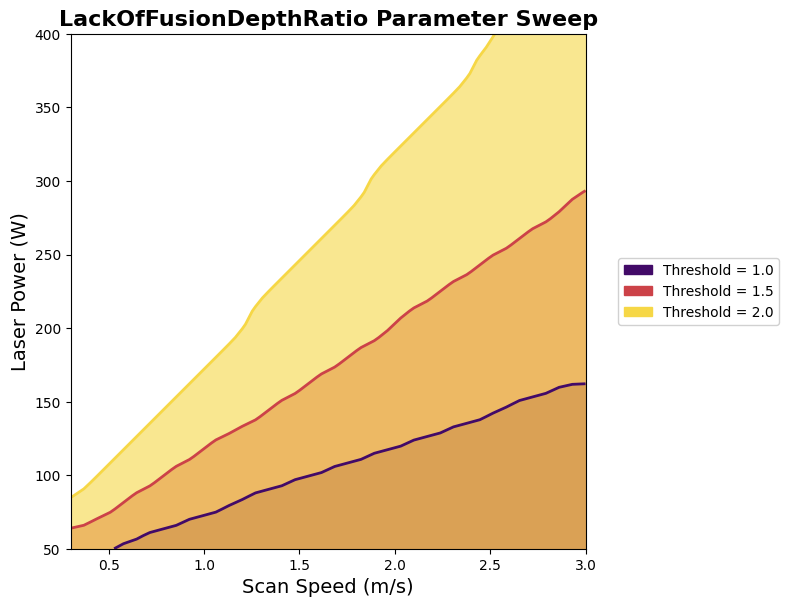

In [17]:
# Sweep the Lack of Fusion criterion across 3 different thresholds
# Standard ratio threshold is 0.5 (penetration depth / layer thickness)
from lpbf_map.defects import LackOfFusionDepthRatioCriterion

fig, ax = space.plot_criterion_sweep(
    criterion_class=LackOfFusionDepthRatioCriterion,
    thresholds=[1.0, 1.5, 2.0],
    x_axis='scan_speed',
    y_axis='laser_power'
)

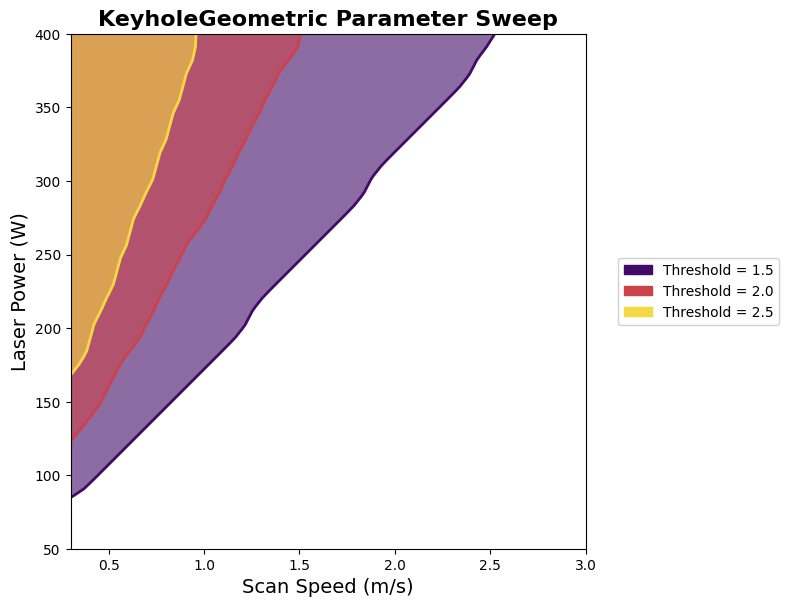

In [15]:
# Sweep the Keyhole Geometric Criterion across 3 different thresholds
from lpbf_map.defects import KeyholeGeometricCriterion

fig, ax = space.plot_criterion_sweep(
    criterion_class=KeyholeGeometricCriterion,
    thresholds=[1.5, 2.0, 2.5],
    x_axis='scan_speed',
    y_axis='laser_power',
    save_path='plots/ti64_keyhole_geometric_sweep.png'
)

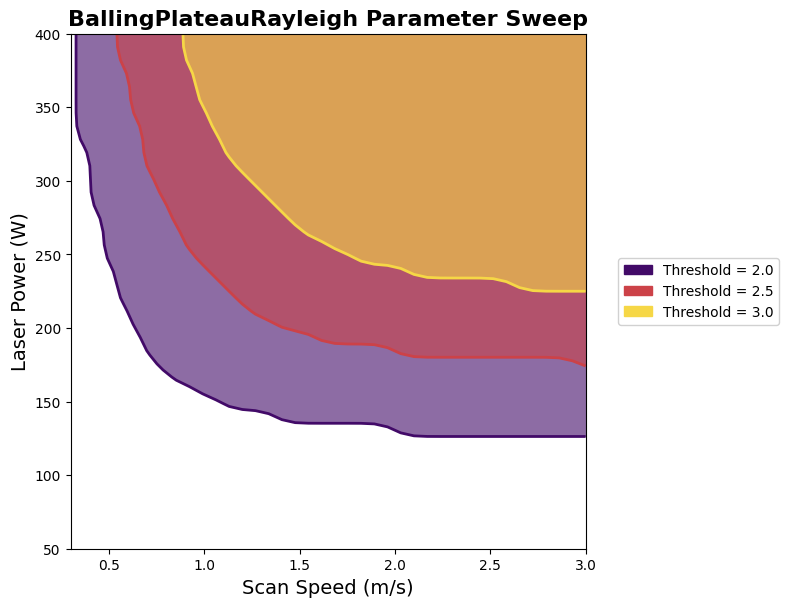

In [16]:
# Sweep the Lack of Fusion criterion across 3 different thresholds
from lpbf_map.defects import BallingPlateauRayleighCriterion

fig, ax = space.plot_criterion_sweep(
    criterion_class=BallingPlateauRayleighCriterion,
    thresholds=[2.0, 2.5, 3.0],
    x_axis='scan_speed',
    y_axis='laser_power'
)